Epoch 1, Loss: 0.6545
Epoch 2, Loss: 0.2803
Epoch 3, Loss: 0.1766
Epoch 4, Loss: 0.1744
Epoch 5, Loss: 0.1210
Epoch 6, Loss: 0.1110
Epoch 7, Loss: 0.0971
Epoch 8, Loss: 0.0900
Epoch 9, Loss: 0.0808
Epoch 10, Loss: 0.0751
Generating Sancāra 1 | Length: 400 | Temperature: 0.55
Generating Sancāra 2 | Length: 400 | Temperature: 0.76
Generating Sancāra 3 | Length: 400 | Temperature: 0.54
Generating Sancāra 4 | Length: 400 | Temperature: 1.48
Generating Sancāra 5 | Length: 400 | Temperature: 0.73
Generating Sancāra 6 | Length: 400 | Temperature: 1.23
Generating Sancāra 7 | Length: 400 | Temperature: 1.38
Generating Sancāra 8 | Length: 400 | Temperature: 1.13
Generating Sancāra 9 | Length: 400 | Temperature: 1.40
Generating Sancāra 10 | Length: 400 | Temperature: 0.98


<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


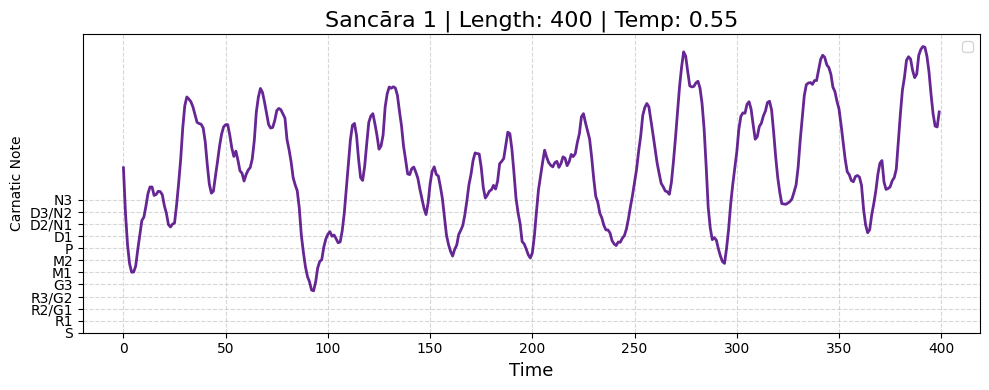

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


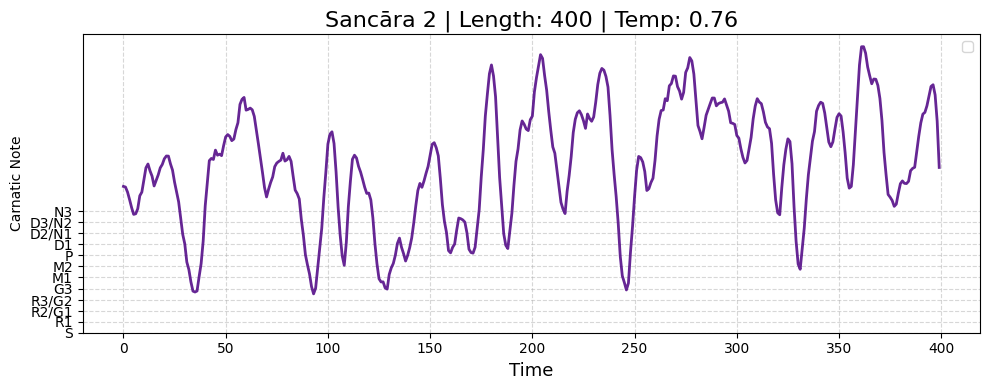

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


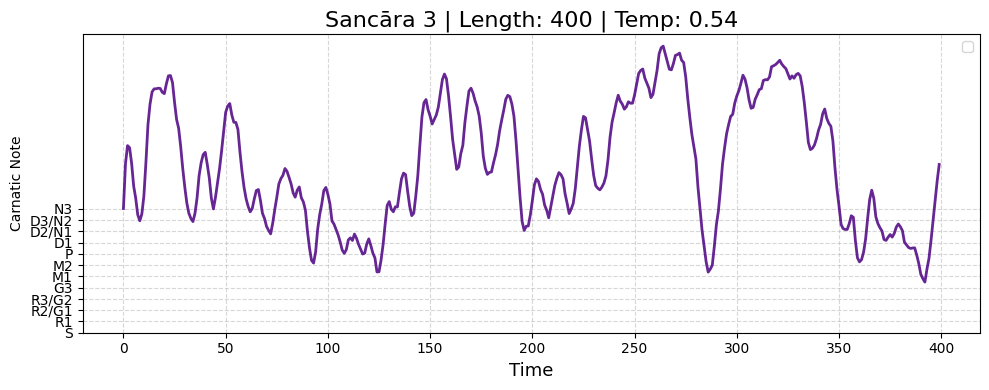

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


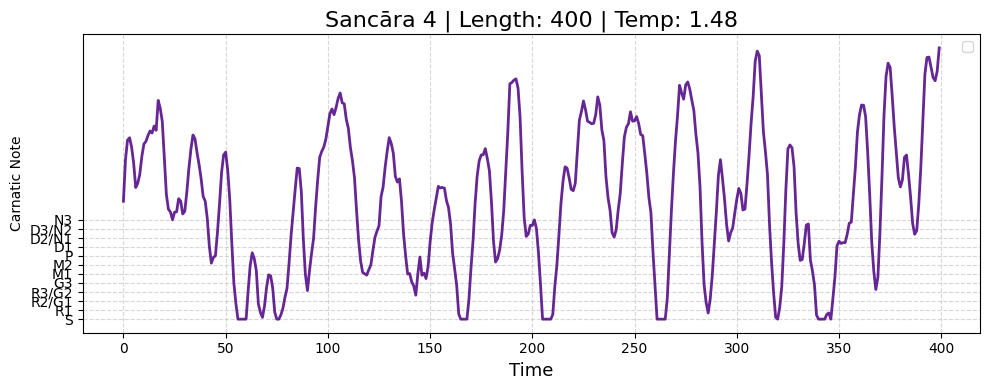

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


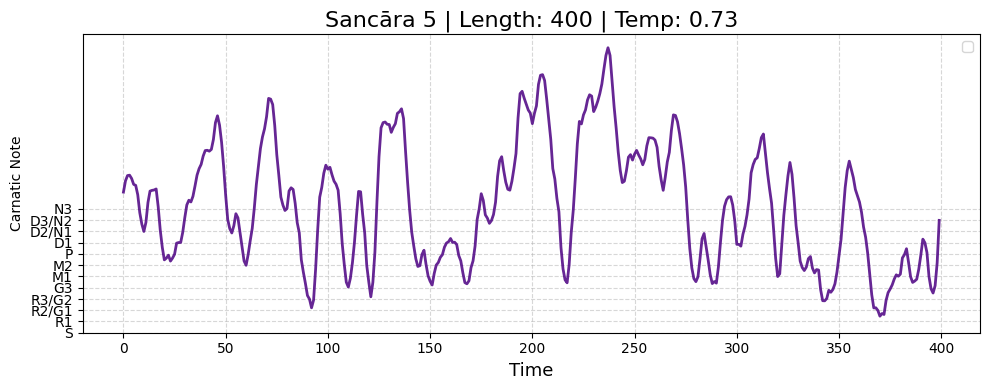

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


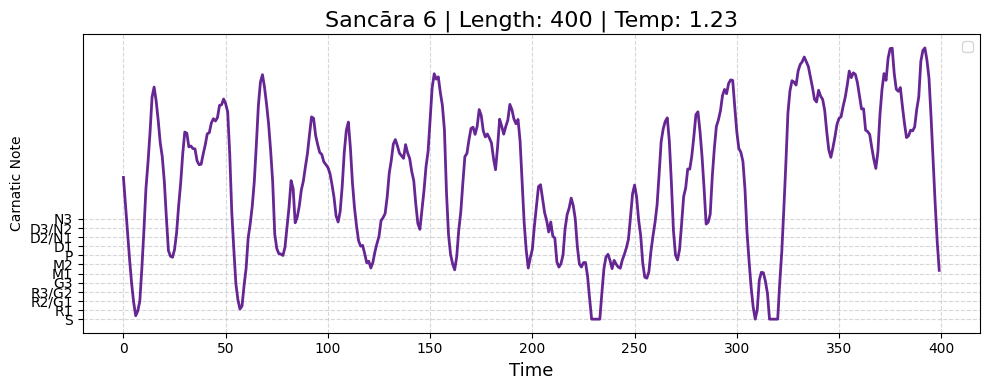

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


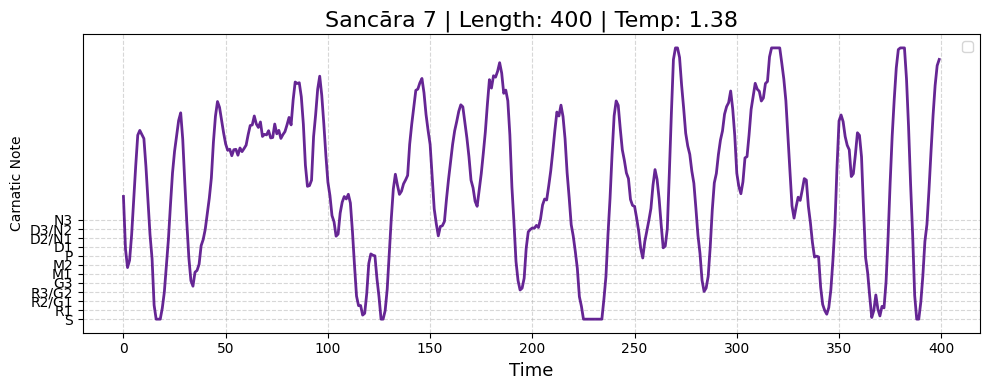

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


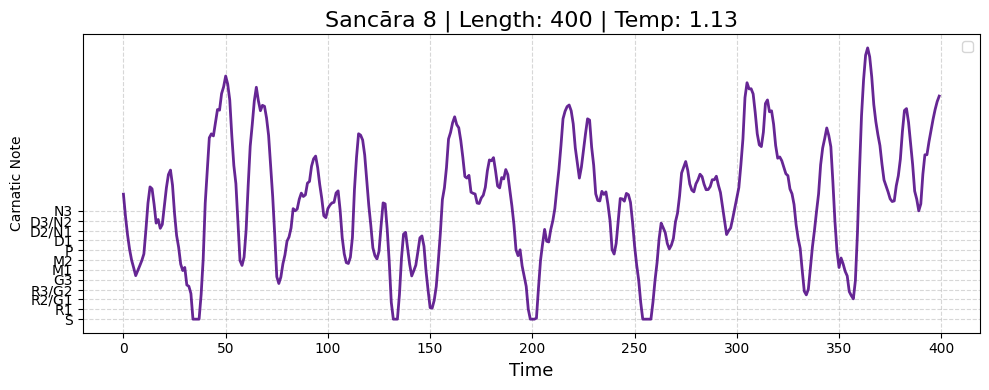

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


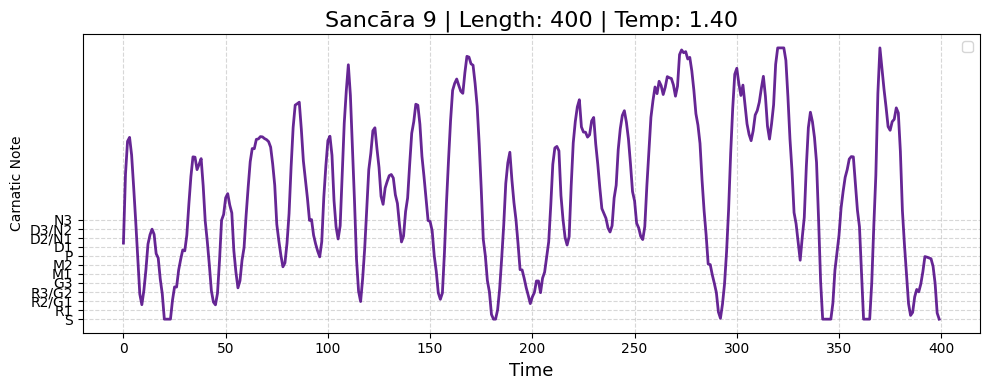

<ipython-input-6-e9db18201edf>:166: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


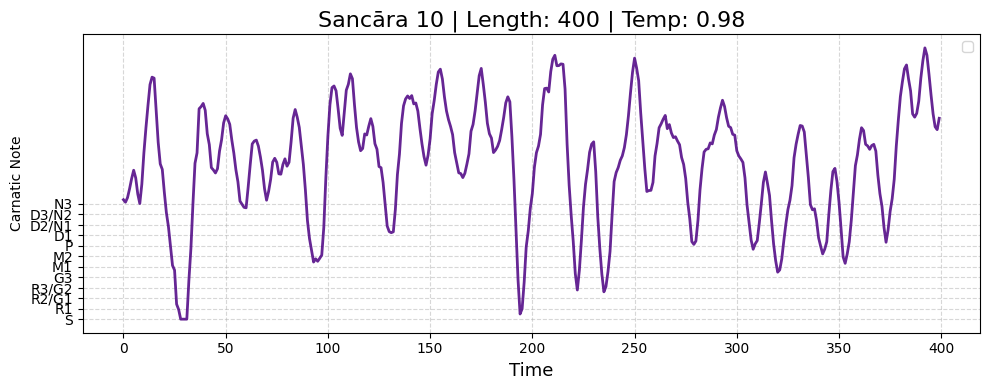

In [6]:
import json
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

# ====================== 1. Load & Normalize Data ======================
with open("only_pitch_cents_grouped.json", "r") as file:
    raw_data = json.load(file)

def pad_with_last_100_pitches(sequences):
    max_len = max(len(seq) for seq in sequences)
    padded_sequences = []

    for seq in sequences:
        if len(seq) < max_len:
            last_100 = seq[-100:] if len(seq) >= 100 else seq  # If less than 100, take as much as possible
            repeats = (max_len - len(seq)) // len(last_100)
            remainder = (max_len - len(seq)) % len(last_100)

            padding = torch.cat([last_100] * repeats + [last_100[:remainder]])
            padded_seq = torch.cat([seq, padding])
        else:
            padded_seq = seq
        padded_sequences.append(padded_seq)

    return torch.stack(padded_sequences)

phrases = [torch.tensor([p for p in seq if p != 0], dtype=torch.float32) for seq in raw_data]
lengths = [len(p) for p in phrases]
max_len = max(lengths)
padded_phrases = pad_with_last_100_pitches(phrases)
mean = padded_phrases[padded_phrases != 0].mean()
std = padded_phrases[padded_phrases != 0].std()
padded_phrases = (padded_phrases - mean) / std

# ====================== 2. Add Noise for Target ======================
def add_slight_variation(tensor, noise_scale=0.05):
    noise = torch.randn_like(tensor) * noise_scale
    return tensor + noise

# ====================== 3. Dataset Class ======================
class PhraseDataset(Dataset):
    def __init__(self, phrases):
        self.inputs = phrases
        self.targets = torch.stack([add_slight_variation(seq) for seq in phrases])

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = PhraseDataset(padded_phrases)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# ====================== 4. Transformer Model ======================
class PhraseTransformer(nn.Module):
    def __init__(self, seq_len, embed_dim=64, heads=4, ff_dim=128, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(1, embed_dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=heads, dim_feedforward=ff_dim, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(embed_dim, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        x = self.input_proj(x) + self.pos_embedding[:, :x.size(1), :]
        x = self.transformer(x)
        x = self.output_proj(x).squeeze(-1)
        return x

# ====================== 5. Training ======================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seq_len = max_len
model = PhraseTransformer(seq_len=seq_len).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(10):
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

# ====================== 6. Helper Functions ======================
def smooth(seq, window=11, polyorder=3):
    if len(seq) < window:
        return seq
    return savgol_filter(seq, window_length=window, polyorder=polyorder)

def clip_pitch_range(seq, min_val=0, max_val=3000):
    return np.clip(seq, min_val, max_val)

# ====================== 7. Generate Sancara ======================
def generate_sancara(model, length, mean, std, start_pitch=0.0, temperature=1.0):
    model.eval()
    seq = torch.zeros(length, dtype=torch.float32).to(device)
    seq[0] = start_pitch

    for i in range(1, length):
        input_seq = seq.clone().unsqueeze(0)
        with torch.no_grad():
            output = model(input_seq)[0, i - 1]
        noise = torch.randn(1).to(device) * temperature
        seq[i] = output + noise

    result = (seq.cpu() * std.item() + mean.item()).numpy()
    result = smooth(result, window=11, polyorder=3)
    result = clip_pitch_range(result, 0, 3000)
    return result
import numpy as np
import matplotlib.pyplot as plt

carnatic_notes = [
    'S',        # 0 cents
    'R1',       # 100 cents
    'R2/G1',    # 200 cents
    'R3/G2',    # 300 cents
    'G3',       # 400 cents
    'M1',       # 500 cents
    'M2',       # 600 cents
    'P',        # 700 cents
    'D1',       # 800 cents
    'D2/N1',    # 900 cents
    'D3/N2',    # 1000 cents
    'N3'        # 1100 cents
]

def pitch_to_carnatic_note_name(pitch):
    """Convert pitch value in cents to Carnatic music note name."""
    note_idx = round(pitch / 100) % 12
    return carnatic_notes[note_idx]

# ====================== 8. Generate and Plot ======================
sancaras = []
length_choices = [400, 400, 400, 400, 400]

for i in range(10):
    length = np.random.choice(length_choices)
    temperature = np.random.uniform(0.5, 1.5)
    print(f"Generating Sancāra {i+1} | Length: {length} | Temperature: {temperature:.2f}")
    sancara = generate_sancara(model, length, mean, std, temperature=temperature)
    sancaras.append((i + 1, length, temperature, sancara))

for idx, length, temp, sancara in sancaras:
    plt.figure(figsize=(10, 4))
    plt.plot(sancara, color="indigo", linewidth=2, alpha=0.85)
    plt.title(f"Sancāra {idx} | Length: {length} | Temp: {temp:.2f}", fontsize=16)
    plt.xlabel("Time", fontsize=13)
    plt.ylabel("Carnatic Note")
    plt.yticks(np.arange(0, 1200, 100), [pitch_to_carnatic_note_name(pitch) for pitch in np.arange(0, 1200, 100)])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()